# Hilbert Spaces and Orthogonal Bases — the One Idea Under Everything

Every expansion this summer — Fourier sines in the grounded slot, Legendre polynomials on the sphere,
Bessel functions in the cylinder / hanging chain / FM spectrum, Hermite functions in the quantum
oscillator — is the *same* move in disguise: project a vector onto an **orthonormal basis** of a
**Hilbert space**.

A Hilbert space is a vector space with an inner product $\langle f,g\rangle$ (and completeness). The
payoff is the **projection theorem**: if $\{e_i\}$ is an orthonormal basis, then
$f=\sum_i\langle e_i,f\rangle\,e_i$ — the coefficients are just inner products. The "different" special
functions are different orthonormal bases of different function spaces; the recipe never changes.

A **phasor** $A e^{i\phi}$ is the simplest Hilbert space (the complex line $\mathbb C$); $L^2$ functions
are the infinite-dimensional case. Engine: `griffiths.hilbert`; summary via pandas.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt
from griffiths import hilbert as hb

x = sp.Symbol("x", real=True)
print("griffiths.hilbert + pandas", pd.__version__, "loaded")

griffiths.hilbert + pandas 2.3.3 loaded


## §1 Inner product, norm, and the phasor

The inner product measures overlap; the norm is length; orthogonal vectors have zero overlap. The
phasor $z=Ae^{i\phi}$ lives in $\mathbb C$ with $\langle z,w\rangle=\bar z\,w$, so $\|z\|^2=A^2$ — the
power. A phasor is the AC-circuit / optics shorthand: freeze the rotating sinusoid $A\cos(\omega t+\phi)$
into one complex number.

In [2]:
A, phi = sp.symbols("A phi", real=True, positive=True)
z = hb.phasor(A, phi)
print("phasor z =", z, "   |z|^2 = <z,z> =", sp.simplify(hb.phasor_inner([z], [z])))

# two phasors and their overlap (correlation / relative phase)
z1, z2 = hb.phasor(1, 0), hb.phasor(1, sp.pi/3)
print("overlap <z1,z2> =", sp.simplify(hb.phasor_inner([z1], [z2])),
      " Re = cos(phase diff) =", sp.re(sp.simplify(hb.phasor_inner([z1], [z2]))))

phasor z = A*exp(I*phi)    |z|^2 = <z,z> = A**2
overlap <z1,z2> = exp(I*pi/3)  Re = cos(phase diff) = 1/2


## §2 Orthogonality is a diagonal Gram matrix

Stack the inner products $G_{ij}=\langle e_i,e_j\rangle$ into the **Gram matrix**. Diagonal means
orthogonal; the identity means orthonormal. Below, the Fourier sines and the Legendre polynomials are
verified orthogonal — their Gram matrices are diagonal (off-diagonal overlaps vanish exactly).

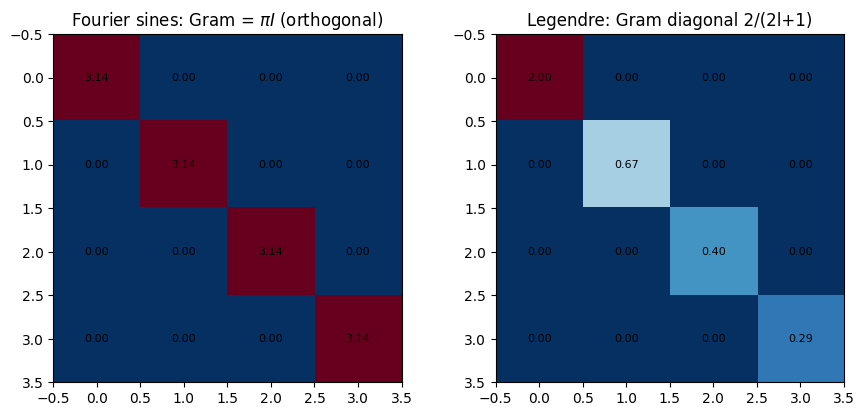

Legendre norms^2: [2, 2/3, 2/5, 2/7]  = 2/(2l+1)


In [3]:
sines = [sp.sin(n*x) for n in range(1, 5)]
legs = [sp.legendre(l, x) for l in range(4)]
Gs = hb.gram_matrix(sines, x, -sp.pi, sp.pi)
Gl = hb.gram_matrix(legs, x, -1, 1)

fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
ax[0].imshow(np.array(Gs.tolist(), dtype=float), cmap="RdBu_r")
ax[0].set_title("Fourier sines: Gram = $\\pi I$ (orthogonal)")
ax[1].imshow(np.array(Gl.tolist(), dtype=float), cmap="RdBu_r")
ax[1].set_title("Legendre: Gram diagonal 2/(2l+1)")
for a, G in zip(ax, (Gs, Gl)):
    for i in range(G.rows):
        for j in range(G.cols):
            a.text(j, i, f"{float(G[i,j]):.2f}", ha="center", va="center", fontsize=8)
plt.tight_layout(); plt.show()
print("Legendre norms^2:", [Gl[i, i] for i in range(4)], " = 2/(2l+1)")

## §3 The orthogonal families — one table

The classical orthonormal bases differ only in their **interval** and **weight**. Loop over them,
let SymPy verify orthogonality, and tabulate with pandas — each is the natural basis of one
boundary-value problem from this session.

In [4]:
families = [
    {"basis": "Fourier  sin(nx)", "interval": "[-pi, pi]", "weight": "1",
     "ortho_relation": "pi*delta", "appeared_in": "slot BVP, FFT, FM"},
    {"basis": "Legendre  P_l(x)", "interval": "[-1, 1]", "weight": "1",
     "ortho_relation": "2/(2l+1)*delta", "appeared_in": "sphere (Ch.3/4/6)"},
    {"basis": "Hermite  H_n(x)", "interval": "(-inf, inf)", "weight": "exp(-x^2)",
     "ortho_relation": "sqrt(pi)2^n n!*delta", "appeared_in": "QM oscillator"},
    {"basis": "Bessel  J_0(a_n x)", "interval": "[0, 1]", "weight": "x",
     "ortho_relation": "J_1(a_n)^2/2*delta", "appeared_in": "cylinder, chain, helix"},
]

# verify orthogonality of the first three symbolically (Bessel checked numerically below)
checks = {
    "Fourier": hb.is_orthogonal([sp.sin(n*x) for n in (1, 2, 3)], x, -sp.pi, sp.pi),
    "Legendre": hb.is_orthogonal([sp.legendre(l, x) for l in range(3)], x, -1, 1),
    "Hermite": hb.is_orthogonal([sp.hermite(n, x) for n in range(3)], x, -sp.oo, sp.oo,
                                weight=sp.exp(-x**2)),
}
# Bessel: numeric Fourier-Bessel orthogonality
import mpmath as mp
a1, a2 = mp.besseljzero(0, 1), mp.besseljzero(0, 2)
cross = mp.quad(lambda r: mp.besselj(0, a1*r)*mp.besselj(0, a2*r)*r, [0, 1])
checks["Bessel"] = abs(cross) < 1e-9

for fam in families:
    fam["verified_orthogonal"] = bool(checks[fam["basis"].split()[0]])
df = pd.DataFrame(families)[["basis", "interval", "weight", "ortho_relation",
                             "verified_orthogonal", "appeared_in"]]
print(df.to_string(index=False))
print("\n<J_0(a_1 r), J_0(a_2 r)>_x =", float(cross), "(~0: Bessel orthogonal under weight x)")

             basis    interval    weight       ortho_relation  verified_orthogonal            appeared_in
  Fourier  sin(nx)   [-pi, pi]         1             pi*delta                 True      slot BVP, FFT, FM
  Legendre  P_l(x)     [-1, 1]         1       2/(2l+1)*delta                 True      sphere (Ch.3/4/6)
   Hermite  H_n(x) (-inf, inf) exp(-x^2) sqrt(pi)2^n n!*delta                 True          QM oscillator
Bessel  J_0(a_n x)      [0, 1]         x   J_1(a_n)^2/2*delta                 True cylinder, chain, helix

<J_0(a_1 r), J_0(a_2 r)>_x = 6.039401537504429e-18 (~0: Bessel orthogonal under weight x)


## §4 Expansion = projection, the same recipe every time

Pick a target function; its coefficients in any orthogonal basis are $c_i=\langle e_i,f\rangle/\langle
e_i,e_i\rangle$. Below, the Fourier-sine series of $f(x)=x$ (coefficients $2(-1)^{n+1}/n$) and its
partial sums marching toward the function — the projection theorem converging in front of you.

Fourier-sine coefficients of f(x)=x:

 [2, -1, 2/3, -1/2, 2/5, -1/3, 2/7]


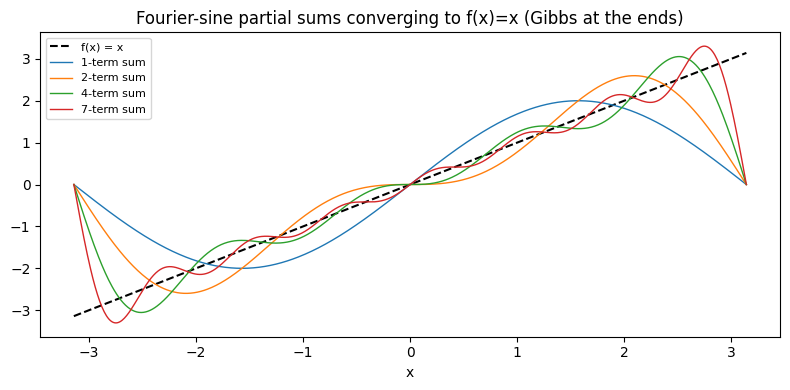

In [5]:
basis = [sp.sin(n*x) for n in range(1, 8)]
coeffs, _ = hb.expand(x, basis, x, -sp.pi, sp.pi)
print("Fourier-sine coefficients of f(x)=x:", coeffs)

xs = np.linspace(-np.pi, np.pi, 600)
plt.figure(figsize=(8, 4))
plt.plot(xs, xs, "k--", lw=1.5, label="f(x) = x")
partial = np.zeros_like(xs)
for n, c in zip(range(1, 8), coeffs):
    partial = partial + float(c)*np.sin(n*xs)
    if n in (1, 2, 4, 7):
        plt.plot(xs, partial, lw=1, label=f"{n}-term sum")
plt.legend(fontsize=8); plt.title("Fourier-sine partial sums converging to f(x)=x (Gibbs at the ends)")
plt.xlabel("x"); plt.tight_layout(); plt.show()

## §5 The unification

- **Every special function is a basis.** Fourier, Legendre, Hermite, Bessel are orthonormal bases of
  $L^2$ on different intervals with different weights. Separation of variables *chooses the basis the
  geometry demands*; the Hilbert-space projection is what you do once you have it. Six notebooks this
  summer were secretly the same theorem.
- **Quantum mechanics is linear algebra in Hilbert space.** States are unit vectors, observables are
  Hermitian operators, measurement is projection onto an eigenbasis, $\langle\psi|\phi\rangle$ is this
  inner product. The `griffiths.quantum` eigensolver returns an orthonormal basis.
- **The FFT and the FNO live here too.** The FFT is the change of basis to $\{e^{ikx}\}$; a spectral
  layer multiplies coefficients in that basis; the FNO *learns* the operator that is diagonal in it.
  The whole TD-GS / phase-retrieval pipeline is projection, constraint, projection — alternating
  between two bases (time and dispersed/Fourier).
- **Phasors** are the 1-D warm-up: AC circuits, optical fields, and the QPSK constellation are all
  vectors in a complex Hilbert space, compared by inner product.

Engine added this session: `griffiths/hilbert.py` (inner product, Gram matrix, orthogonality check,
basis expansion, phasors), benchmarked in `scripts/smoke_hilbert.py`.